# WTI MM COT Surprise — Stripping Out the Price Component

Decompose the weekly MM net positioning change into:
- **Price-explained**: the trend-following part driven by recent price returns
- **Surprise (residual)**: the part NOT explained by price action

Then test: does the surprise component predict future price returns?
If yes, there's genuine information in MM flows beyond mechanical trend-following.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from sklearn.linear_model import LinearRegression

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load and join COT + Prices

In [2]:
COT_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cftc_data/cftc_downloads/disaggregated_combined.csv'

raw = pd.read_csv(COT_PATH, low_memory=False)
wti = raw[raw['contract_market_name'] == 'WTI-PHYSICAL'].copy()

wti['as_of_date'] = pd.to_datetime(wti['report_date_as_yyyy_mm_dd'])
days_ahead = (4 - wti['as_of_date'].dt.dayofweek) % 7
wti['release_date'] = wti['as_of_date'] + pd.to_timedelta(days_ahead, unit='D')
wti['open_interest'] = pd.to_numeric(wti['open_interest_all'], errors='coerce')
wti['mm_net'] = (pd.to_numeric(wti['m_money_positions_long_all'], errors='coerce')
               - pd.to_numeric(wti['m_money_positions_short_all'], errors='coerce'))
wti.sort_values('as_of_date', inplace=True)
wti.reset_index(drop=True, inplace=True)

cot = wti[['as_of_date', 'release_date', 'mm_net', 'open_interest']].copy()

# Prices
prices = pd.read_csv('../../cache/preprocessed_data/wti_prices_panel.csv',
                      usecols=['tradeDate', 'F1_RolledPrice'])
prices['tradeDate'] = pd.to_datetime(prices['tradeDate'])
prices.sort_values('tradeDate', inplace=True)

# Join on release_date
df = pd.merge_asof(
    cot.sort_values('release_date'),
    prices.rename(columns={'tradeDate': 'release_date'}),
    on='release_date', direction='backward', tolerance=pd.Timedelta(days=3),
)
df.dropna(subset=['mm_net', 'F1_RolledPrice', 'open_interest'], inplace=True)
df.sort_values('as_of_date', inplace=True)
df.reset_index(drop=True, inplace=True)

# Weekly changes
df['mm_net_chg'] = df['mm_net'].diff()
df['mm_net_oi_chg'] = (df['mm_net'] / df['open_interest']).diff() * 100
df['price_ret'] = df['F1_RolledPrice'].pct_change() * 100

# Lagged price returns (for regression)
for lag in range(1, 5):
    df[f'price_ret_lag{lag}'] = df['price_ret'].shift(lag)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Rows: {len(df)}')
print(f'Range: {df["as_of_date"].min().date()} -> {df["as_of_date"].max().date()}')

Rows: 809
Range: 2010-02-09 -> 2025-08-05


## 2. Regress COT change on price returns

```
COT_change_t = α + β₀·price_ret_t + β₁·price_ret_{t-1} + ... + β₃·price_ret_{t-3} + ε_t
```

The residual `ε_t` is the **surprise** — the part of MM's positioning
change that isn't explained by recent price action.

In [3]:
price_features = ['price_ret', 'price_ret_lag1', 'price_ret_lag2', 'price_ret_lag3']

X = df[price_features].values
y_raw = df['mm_net_chg'].values
y_oi  = df['mm_net_oi_chg'].values

# Fit OLS
reg_raw = LinearRegression().fit(X, y_raw)
reg_oi  = LinearRegression().fit(X, y_oi)

df['mm_net_chg_predicted'] = reg_raw.predict(X)
df['mm_net_chg_surprise']  = y_raw - df['mm_net_chg_predicted']

df['mm_net_oi_chg_predicted'] = reg_oi.predict(X)
df['mm_net_oi_chg_surprise']  = y_oi - df['mm_net_oi_chg_predicted']

r2_raw = reg_raw.score(X, y_raw)
r2_oi  = reg_oi.score(X, y_oi)

print('Regression: COT change ~ price_ret + lag1 + lag2 + lag3')
print(f'  Raw net change R² = {r2_raw:.3f}')
print(f'  Net/OI change  R² = {r2_oi:.3f}')
print()
print('Coefficients (raw net change):')
for f, b in zip(price_features, reg_raw.coef_):
    print(f'  {f:18s}  β = {b:+.1f}')
print(f'  {"intercept":18s}  α = {reg_raw.intercept_:+.1f}')

Regression: COT change ~ price_ret + lag1 + lag2 + lag3
  Raw net change R² = 0.022
  Net/OI change  R² = 0.013

Coefficients (raw net change):
  price_ret           β = +46.0
  price_ret_lag1      β = +94.4
  price_ret_lag2      β = +46.3
  price_ret_lag3      β = +56.7
  intercept           α = -346.4


## 3. Visualise: actual vs predicted vs surprise

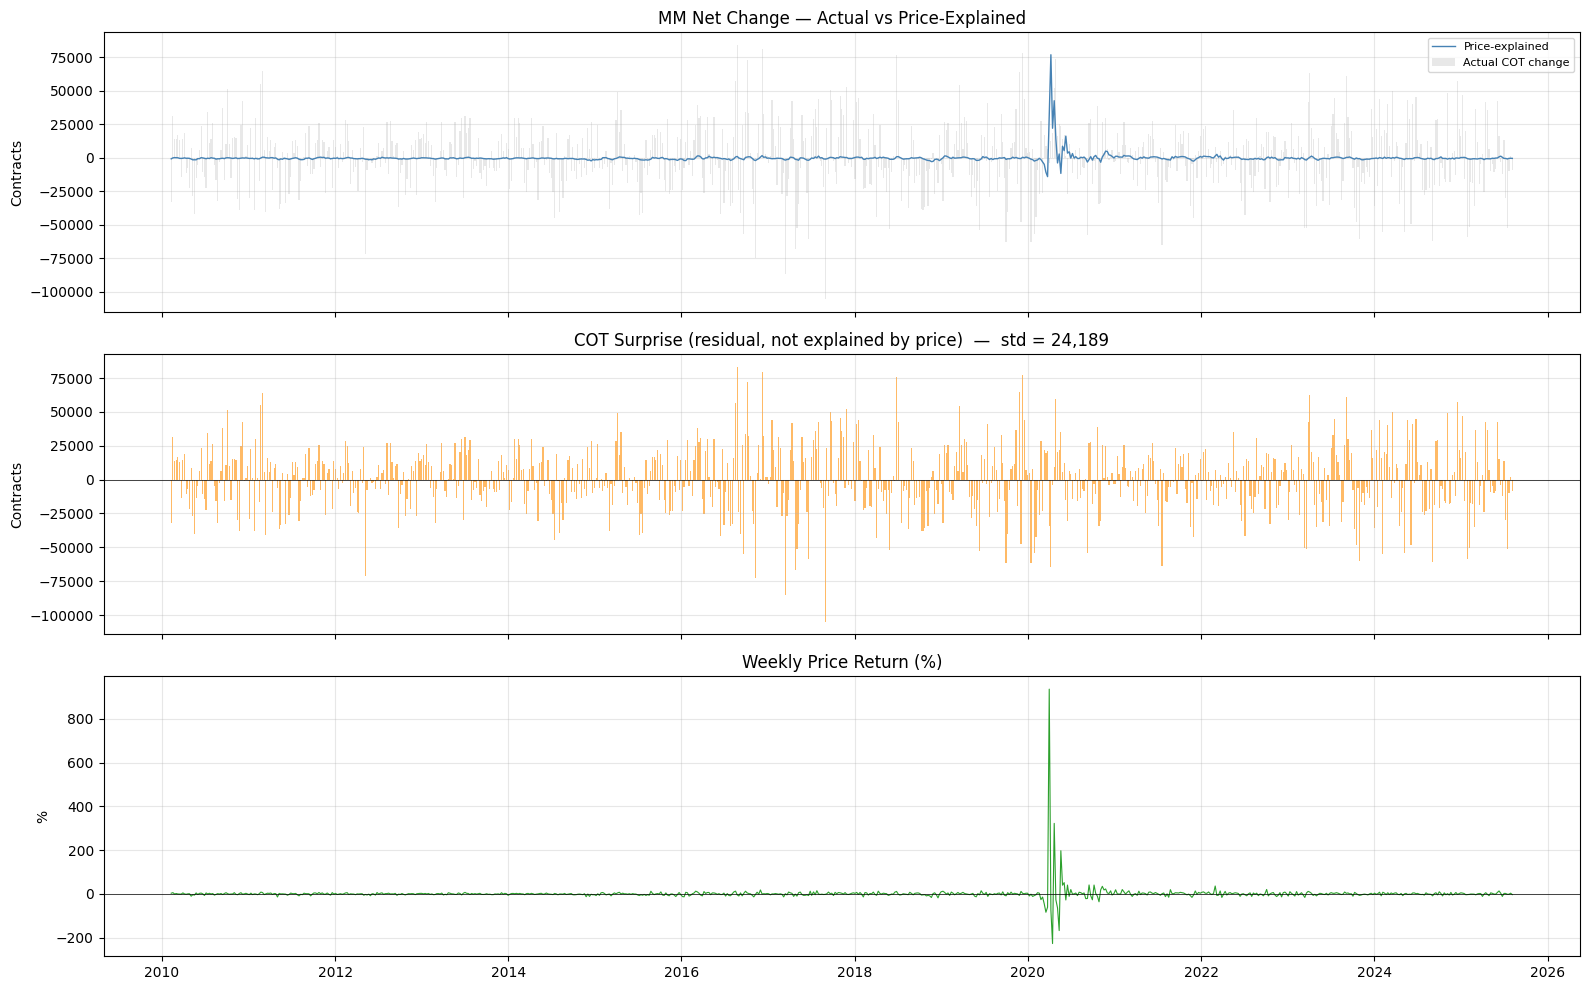

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

ax = axes[0]
ax.bar(df['as_of_date'], df['mm_net_chg'], width=5, alpha=0.5,
       color='lightgrey', label='Actual COT change')
ax.plot(df['as_of_date'], df['mm_net_chg_predicted'],
        color='steelblue', lw=1, label='Price-explained')
ax.set_title('MM Net Change — Actual vs Price-Explained')
ax.set_ylabel('Contracts')
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(df['as_of_date'], df['mm_net_chg_surprise'], width=5,
       color='darkorange', alpha=0.6)
ax.axhline(0, color='black', lw=0.5)
ax.set_title(f'COT Surprise (residual, not explained by price)  —  std = {df["mm_net_chg_surprise"].std():,.0f}')
ax.set_ylabel('Contracts')

ax = axes[2]
ax.plot(df['as_of_date'], df['price_ret'], color='tab:green', lw=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Weekly Price Return (%)')
ax.set_ylabel('%')

plt.tight_layout()
plt.show()

## 4. CCF: does the surprise predict future price?

This is the key test. If the surprise has positive lag +1, +2, etc.
correlation with future price returns, then MM's non-trend-following
flows contain genuine information about future prices.

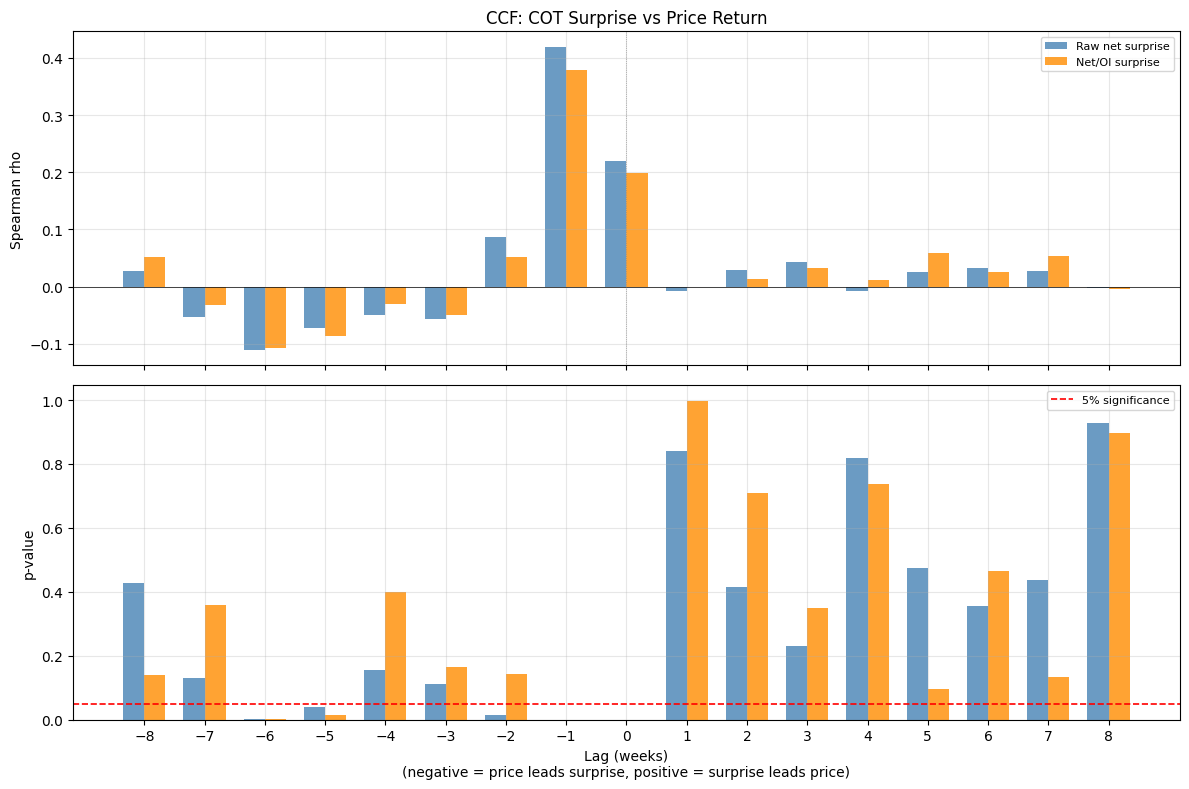

 Lag   rho (raw)       p-val    rho (OI)       p-val  Interpretation
-------------------------------------------------------------------------------------
  -8     +0.028       4.3e-01     +0.052       1.4e-01  price leads surprise by 8w
  -7     -0.054       1.3e-01     -0.033       3.6e-01  price leads surprise by 7w
  -6     -0.111 *     1.6e-03     -0.107 *     2.4e-03  price leads surprise by 6w
  -5     -0.072 *     4.0e-02     -0.087 *     1.3e-02  price leads surprise by 5w
  -4     -0.050       1.6e-01     -0.030       4.0e-01  price leads surprise by 4w
  -3     -0.056       1.1e-01     -0.049       1.7e-01  price leads surprise by 3w
  -2     +0.087 *     1.4e-02     +0.052       1.4e-01  price leads surprise by 2w
  -1     +0.420 *     7.3e-36     +0.380 *     4.4e-29  price leads surprise by 1w
   0     +0.220 *     2.6e-10     +0.198 *     1.3e-08  same week
   1     -0.007       8.4e-01     +0.000       1.0e+00  surprise leads price by 1w
   2     +0.029       4.1e-01   

In [5]:
MAX_LAG = 8

def compute_ccf(x, y, max_lag):
    lags = range(-max_lag, max_lag + 1)
    rhos, pvals = [], []
    for k in lags:
        if k >= 0:
            rho, p = sp_stats.spearmanr(x[:len(x)-k], y[k:])
        else:
            rho, p = sp_stats.spearmanr(x[-k:], y[:len(y)+k])
        rhos.append(rho)
        pvals.append(p)
    return list(lags), rhos, pvals

# CCF: raw surprise vs price
surprise_raw = df['mm_net_chg_surprise'].values
surprise_oi  = df['mm_net_oi_chg_surprise'].values
price_vals   = df['price_ret'].values

lags, rhos_raw, pvals_raw = compute_ccf(surprise_raw, price_vals, MAX_LAG)
_, rhos_oi, pvals_oi = compute_ccf(surprise_oi, price_vals, MAX_LAG)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
bar_width = 0.35
x_pos = np.array(lags)

ax = axes[0]
ax.bar(x_pos - bar_width/2, rhos_raw, bar_width, color='steelblue',
       alpha=0.8, label='Raw net surprise')
ax.bar(x_pos + bar_width/2, rhos_oi, bar_width, color='darkorange',
       alpha=0.8, label='Net/OI surprise')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_ylabel('Spearman rho')
ax.set_title('CCF: COT Surprise vs Price Return')
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(x_pos - bar_width/2, pvals_raw, bar_width, color='steelblue', alpha=0.8)
ax.bar(x_pos + bar_width/2, pvals_oi, bar_width, color='darkorange', alpha=0.8)
ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% significance')
ax.set_ylabel('p-value')
ax.set_xlabel('Lag (weeks)\n'
              '(negative = price leads surprise, positive = surprise leads price)')
ax.set_xticks(lags)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'{"Lag":>4s}  {"rho (raw)":>10s}  {"p-val":>10s}  {"rho (OI)":>10s}  {"p-val":>10s}  Interpretation')
print('-' * 85)
for k, rr, pr, ro, po in zip(lags, rhos_raw, pvals_raw, rhos_oi, pvals_oi):
    sig_r = '*' if pr < 0.05 else ' '
    sig_o = '*' if po < 0.05 else ' '
    if k < 0:
        interp = f'price leads surprise by {-k}w'
    elif k == 0:
        interp = 'same week'
    else:
        interp = f'surprise leads price by {k}w'
    print(f'{k:>4d}  {rr:>+9.3f} {sig_r}  {pr:>10.1e}  {ro:>+9.3f} {sig_o}  {po:>10.1e}  {interp}')

## 5. Comparison: raw COT change vs surprise

Side by side: did stripping out price improve the
predictive signal at positive lags?

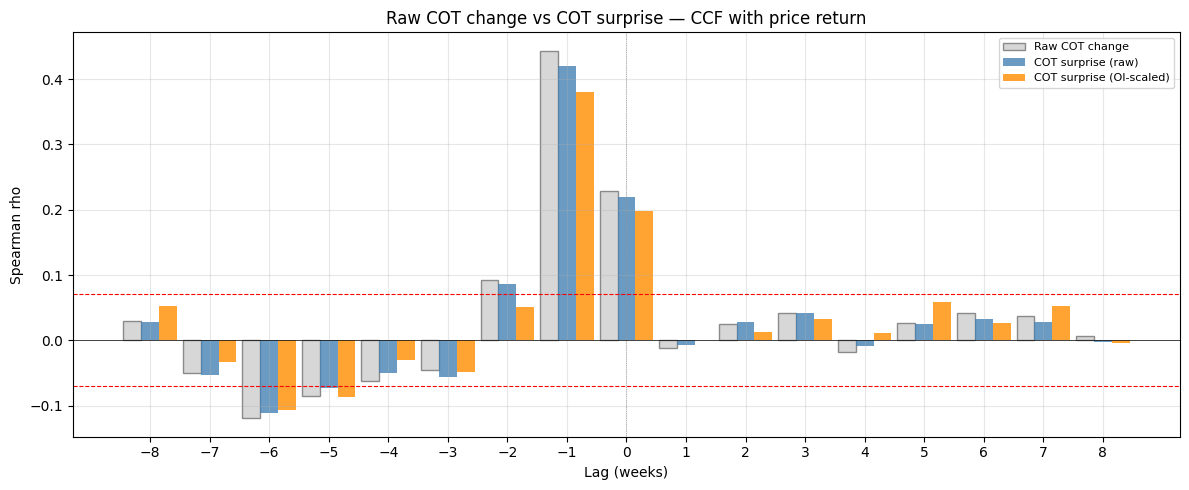

 Lag     Raw COT    Surprise   Surprise/OI
---------------------------------------------
   0      +0.229      +0.220        +0.198
   1      -0.011      -0.007        +0.000
   2      +0.025      +0.029        +0.013
   3      +0.042      +0.042        +0.033
   4      -0.018      -0.008        +0.012
   5      +0.026      +0.025        +0.059
   6      +0.043      +0.033        +0.026
   7      +0.038      +0.027        +0.053
   8      +0.006      -0.003        -0.005


In [6]:
# Also compute CCF for the raw (un-orthogonalised) COT change
mm_raw = df['mm_net_chg'].values
_, rhos_orig, _ = compute_ccf(mm_raw, price_vals, MAX_LAG)

fig, ax = plt.subplots(figsize=(12, 5))
bar_width = 0.3
ax.bar(x_pos - bar_width, rhos_orig, bar_width, color='lightgrey',
       alpha=0.9, label='Raw COT change', edgecolor='grey')
ax.bar(x_pos, rhos_raw, bar_width, color='steelblue',
       alpha=0.8, label='COT surprise (raw)')
ax.bar(x_pos + bar_width, rhos_oi, bar_width, color='darkorange',
       alpha=0.8, label='COT surprise (OI-scaled)')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
sig = 2 / np.sqrt(len(df))
ax.axhline(sig, color='red', linestyle='--', lw=0.8)
ax.axhline(-sig, color='red', linestyle='--', lw=0.8)
ax.set_xlabel('Lag (weeks)')
ax.set_ylabel('Spearman rho')
ax.set_title('Raw COT change vs COT surprise — CCF with price return')
ax.set_xticks(lags)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Summary: positive lags only (predictive direction)
print(f'{"Lag":>4s}  {"Raw COT":>10s}  {"Surprise":>10s}  {"Surprise/OI":>12s}')
print('-' * 45)
for k, ro, rs, rso in zip(lags, rhos_orig, rhos_raw, rhos_oi):
    if k >= 0:
        print(f'{k:>4d}  {ro:>+10.3f}  {rs:>+10.3f}  {rso:>+12.3f}')

## 6. Rolling surprise: does the signal change over time?

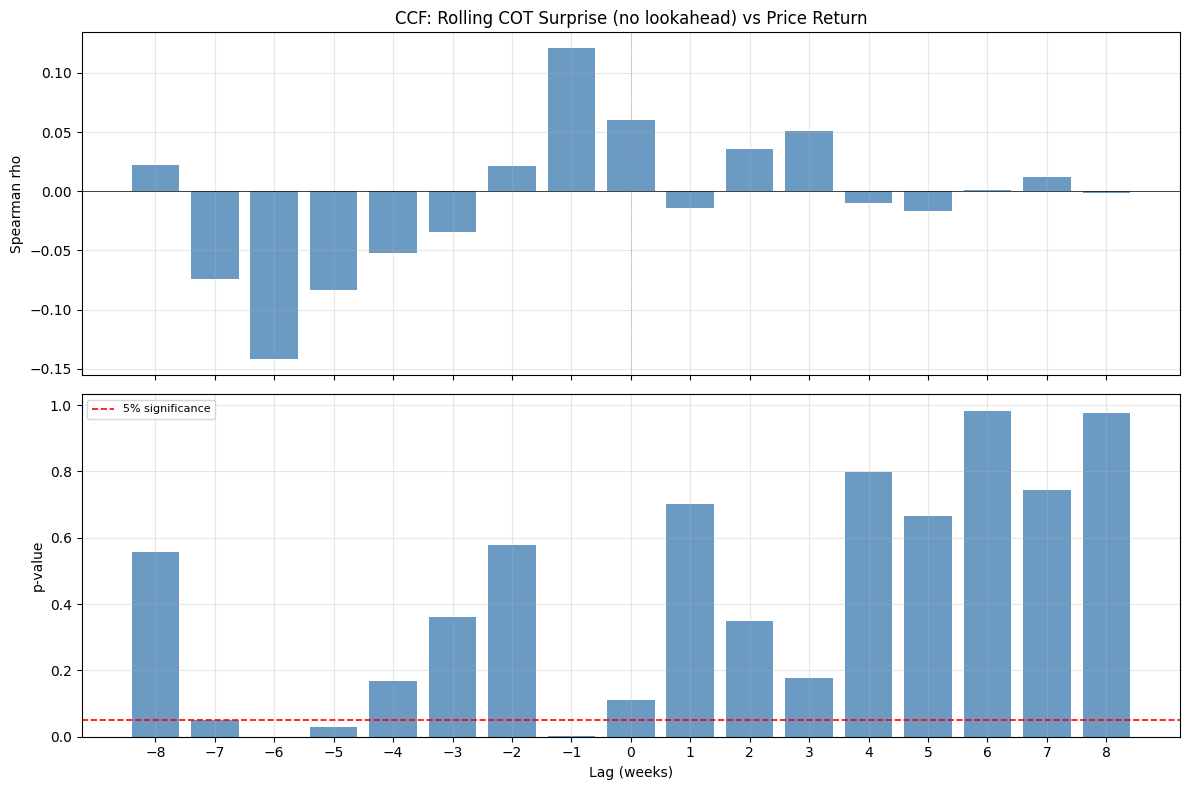


 Lag       rho       p-val
----------------------------
  -8   +0.022       5.6e-01
  -7   -0.074       5.1e-02
  -6   -0.142 *     1.7e-04
  -5   -0.083 *     2.8e-02
  -4   -0.052       1.7e-01
  -3   -0.035       3.6e-01
  -2   +0.021       5.8e-01
  -1   +0.121 *     1.3e-03
   0   +0.060       1.1e-01
   1   -0.014       7.0e-01
   2   +0.035       3.5e-01
   3   +0.051       1.8e-01
   4   -0.010       8.0e-01
   5   -0.016       6.7e-01
   6   +0.001       9.8e-01
   7   +0.012       7.4e-01
   8   -0.001       9.8e-01


In [7]:
# Rolling regression: recompute surprise with expanding window
# so there's no lookahead in the orthogonalisation
MIN_TRAIN = 104  # 2 years

surprise_rolling = np.full(len(df), np.nan)
for t in range(MIN_TRAIN, len(df)):
    X_train = df[price_features].values[:t]
    y_train = df['mm_net_chg'].values[:t]
    reg = LinearRegression().fit(X_train, y_train)
    predicted = reg.predict(df[price_features].values[t:t+1])[0]
    surprise_rolling[t] = df['mm_net_chg'].values[t] - predicted

df['surprise_rolling'] = surprise_rolling

# CCF on the rolling surprise (no lookahead)
valid = df.dropna(subset=['surprise_rolling'])
sr_vals = valid['surprise_rolling'].values
pr_vals = valid['price_ret'].values

lags_r, rhos_r, pvals_r = compute_ccf(sr_vals, pr_vals, MAX_LAG)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.bar(lags_r, rhos_r, color='steelblue', alpha=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_ylabel('Spearman rho')
ax.set_title('CCF: Rolling COT Surprise (no lookahead) vs Price Return')

ax = axes[1]
ax.bar(lags_r, pvals_r, color='steelblue', alpha=0.8)
ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% significance')
ax.set_ylabel('p-value')
ax.set_xlabel('Lag (weeks)')
ax.set_xticks(lags_r)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'\n{"Lag":>4s}  {"rho":>8s}  {"p-val":>10s}')
print('-' * 28)
for k, r, p in zip(lags_r, rhos_r, pvals_r):
    sig = '*' if p < 0.05 else ' '
    print(f'{k:>4d}  {r:>+7.3f} {sig}  {p:>10.1e}')

## 7. If surprise predicts price: simple backtest

Go long if this week's surprise > 0 (MM bought more than expected),
short if < 0. Evaluate on next week's return.

Backtest: 704 weeks
Strategy: go long/short based on COT surprise sign

  Hit rate:        49.4%
  Sharpe (ann):    0.09
  Buy-and-hold SR: 0.25
  Mean weekly ret: 0.505%


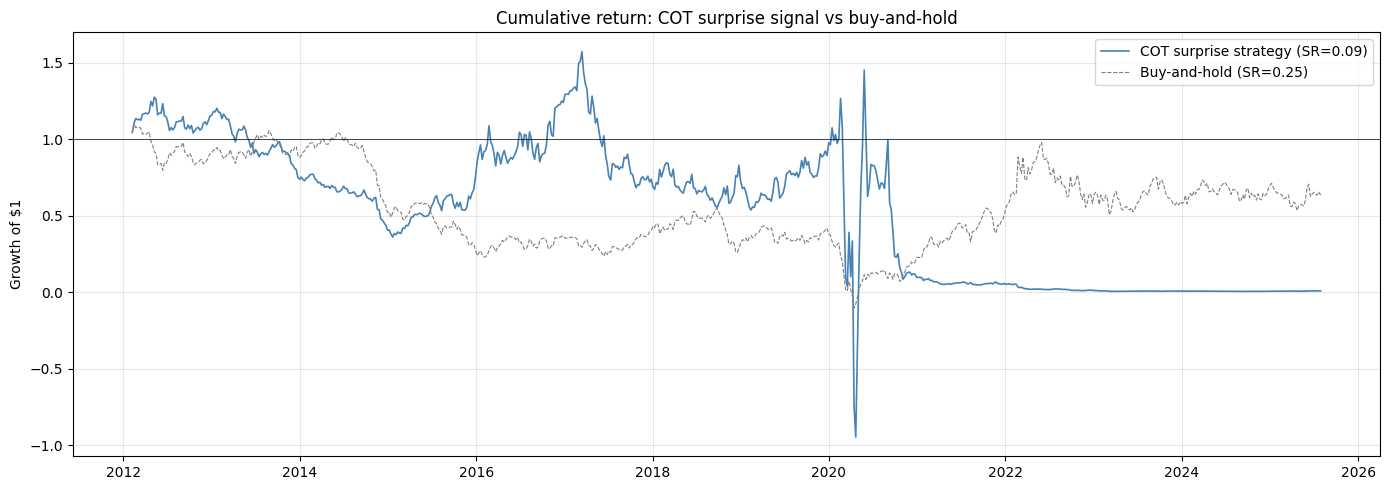

In [8]:
valid = df.dropna(subset=['surprise_rolling']).copy()
valid['next_price_ret'] = valid['price_ret'].shift(-1)
valid.dropna(subset=['next_price_ret'], inplace=True)

valid['signal'] = np.sign(valid['surprise_rolling'])
valid['strategy_ret'] = valid['signal'] * valid['next_price_ret']

# Cumulative returns
valid['cum_strategy'] = (1 + valid['strategy_ret'] / 100).cumprod()
valid['cum_long'] = (1 + valid['next_price_ret'] / 100).cumprod()

# Stats
ann_factor = np.sqrt(52)
sr_strat = valid['strategy_ret'].mean() / valid['strategy_ret'].std() * ann_factor
sr_long  = valid['next_price_ret'].mean() / valid['next_price_ret'].std() * ann_factor
hit_rate = (valid['strategy_ret'] > 0).mean()

print(f'Backtest: {len(valid)} weeks')
print(f'Strategy: go long/short based on COT surprise sign')
print(f'\n  Hit rate:        {hit_rate:.1%}')
print(f'  Sharpe (ann):    {sr_strat:.2f}')
print(f'  Buy-and-hold SR: {sr_long:.2f}')
print(f'  Mean weekly ret: {valid["strategy_ret"].mean():.3f}%')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(valid['as_of_date'], valid['cum_strategy'],
        color='steelblue', lw=1.2, label=f'COT surprise strategy (SR={sr_strat:.2f})')
ax.plot(valid['as_of_date'], valid['cum_long'],
        color='grey', lw=0.8, linestyle='--', label=f'Buy-and-hold (SR={sr_long:.2f})')
ax.axhline(1, color='black', lw=0.5)
ax.set_title('Cumulative return: COT surprise signal vs buy-and-hold')
ax.set_ylabel('Growth of $1')
ax.legend()
plt.tight_layout()
plt.show()